In [1]:

from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI

In [2]:
load_dotenv()

True

In [3]:
model = ChatOpenAI(model = "gpt-4o-mini")

In [4]:
# define the state:

class BlogState(TypedDict):

    title: str 
    outline: str 
    content: str 
    score: int

In [5]:
def create_outline(state: BlogState)->BlogState:
    
    title = state['title']

     # define the prompt for this 
    prompt = f'generate a details outline for a blog on the topic {title}'

    # call the llm 
    outline= model.invoke(prompt)

    # update the state.
    state['outline'] = outline

    return state


def create_blog(state: BlogState) -> BlogState:
   # extract the title and outline
    title = state['title']
    outline = state['outline']

    # define the prompt
    prompt = f'Write a detailed blog on the title {title} by uisng the  following outline\n {outline}'

    # call the llm
    content = model.invoke(prompt)
    state['content'] = content
    return state

def eval_score(state: BlogState) -> BlogState:
    
    outline = state['outline']
    blog = state['outline']

    prompt = f'Based on given outline {outline} can you rate my blog \n {blog} and provide me the  score in integer formatt'

    score = model.invoke(prompt)
    state['score']= score

    return state

In [6]:
# define the graph:

graph = StateGraph(BlogState)

# define the node.
graph.add_node('create_outline', create_outline)
graph.add_node('create_blog', create_blog)
graph.add_node('eval_score', eval_score)

# add the edge.
graph.add_edge(START, 'create_outline')
graph.add_edge('create_outline', 'create_blog')
graph.add_edge('create_blog','eval_score')
graph.add_edge('eval_score', END)

# compile the graph
workflow = graph.compile()


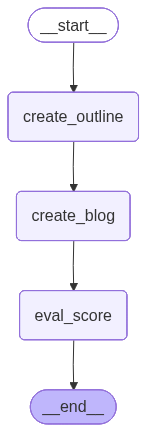

In [7]:
from IPython.display import Image

Image(
    workflow.get_graph().draw_mermaid_png()
)

In [8]:
initial_state = {'title': 'Raise of AI in India'}

final_state = workflow.invoke(initial_state)
print(final_state)

print('-------')
print(final_state.keys())
print(final_state['score'])

{'title': 'Raise of AI in India', 'outline': AIMessage(content="# Blog Outline: The Rise of AI in India\n\n## I. Introduction\n   A. Definition of Artificial Intelligence (AI)\n   B. Overview of the significance of AI in today’s world\n   C. Brief introduction to the landscape of AI in India\n\n## II. Historical Context\n   A. Early developments in AI globally and in India\n   B. Key milestones in the evolution of AI in India\n      1. Government initiatives\n      2. Academic contributions\n      3. Private sector innovations\n\n## III. Current State of AI in India\n   A. Government Policies and Initiatives\n      1. National AI Strategy\n      2. “AI for All” initiative\n      3. Investments in AI research and infrastructure\n   B. Role of Academic Institutions\n      1. Notable universities and research institutions\n      2. AI research projects and collaborations\n   C. Corporate Sector Contributions\n      1. Major tech companies leveraging AI\n      2. Startups driving AI innova